In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from abc import ABC, abstractmethod
import numpy as np
from sklearn.metrics import classification_report, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVR, SVC
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier

In [24]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [2]:
data = pd.read_csv('hour.csv')
X = data.drop(['cnt','instant','dteday'], axis=1).values
y = data['cnt'].values

scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)


scaler_y = StandardScaler()
y = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Признаков: {X.shape[1]}, Объектов: {X.shape[0]}")




Признаков: 14, Объектов: 17379


In [3]:
model = DecisionTreeRegressor(
    criterion='squared_error',
    splitter='best',
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=42,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    ccp_alpha=0.0,
    monotonic_cst=None
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

score = model.score(X_test, y_test)
print(score)
mean_absolute_error(y_pred, y_test)

0.9988856383739698


0.018029415484870737

In [12]:
model = RandomForestRegressor(
    n_estimators=200,
    criterion='absolute_error',
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=3,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=-1,
    random_state=42,
    verbose=0,
    warm_start=False,
    ccp_alpha=0.0,
    max_samples=None
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

score = model.score(X_test, y_test)
print(score)
mean_absolute_error(y_pred, y_test)

0.9938063861411326


0.04184970465482154

In [16]:
model = CatBoostRegressor(iterations=1000, learning_rate=0.01, depth=5)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

score = model.score(X_test, y_test)
print(score)
mean_absolute_error(y_pred, y_test)

0:	learn: 0.9955490	total: 2.51ms	remaining: 2.51s
1:	learn: 0.9866509	total: 4.72ms	remaining: 2.36s
2:	learn: 0.9777750	total: 7.02ms	remaining: 2.33s
3:	learn: 0.9690492	total: 9.27ms	remaining: 2.31s
4:	learn: 0.9603045	total: 11.1ms	remaining: 2.21s
5:	learn: 0.9516350	total: 13.1ms	remaining: 2.17s
6:	learn: 0.9431503	total: 15ms	remaining: 2.12s
7:	learn: 0.9346664	total: 17ms	remaining: 2.11s
8:	learn: 0.9261569	total: 19.6ms	remaining: 2.16s
9:	learn: 0.9180765	total: 21.2ms	remaining: 2.1s
10:	learn: 0.9099083	total: 22.9ms	remaining: 2.06s
11:	learn: 0.9018484	total: 24.8ms	remaining: 2.04s
12:	learn: 0.8938599	total: 27.1ms	remaining: 2.06s
13:	learn: 0.8856934	total: 29.2ms	remaining: 2.06s
14:	learn: 0.8779284	total: 30.9ms	remaining: 2.03s
15:	learn: 0.8705016	total: 32.7ms	remaining: 2.01s
16:	learn: 0.8627597	total: 34.8ms	remaining: 2.01s
17:	learn: 0.8554414	total: 37ms	remaining: 2.02s
18:	learn: 0.8480771	total: 39.2ms	remaining: 2.02s
19:	learn: 0.8404507	total: 4

0.009712501684159953

In [17]:
model = LGBMRegressor( max_depth=5, learning_rate=0.1, n_estimators=100)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

score = model.score(X_test, y_test)
print(score)
mean_absolute_error(y_pred, y_test)

0.9996208661432449


0.009537709040821898

In [20]:
model2 = XGBRegressor( max_depth=5, learning_rate=0.1, n_estimators=100)
model2.fit(X_train, y_train)

y_pred = model2.predict(X_test)

score = model2.score(X_test, y_test)
print(score)
mean_absolute_error(y_pred, y_test)

0.9996103402872583


0.009769014784373423

In [23]:
df = pd.read_csv('bank-additional-full.csv', delimiter=';', decimal='.')
print(df.columns.tolist())
print(df)
data = pd.get_dummies(df, columns=["job","marital","education","default","housing","loan","contact","month","day_of_week",'poutcome',])

data = data.dropna(axis=1, how='all')  
data.fillna(data.mean(numeric_only=True), inplace=True)
X = data.drop(['y'], axis=1).values
le = LabelEncoder()
y = le.fit_transform(data['y'].values)
#y = data['Class'].values
#y_decoded = le.inverse_transform(y_encoded)  

print(f"Признаков: {X.shape[1]}, Объектов: {X.shape[0]}")

print(pd.Series(y).value_counts())



scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
       age          job  marital            education  default housing loan  \
0       56    housemaid  married             basic.4y       no      no   no   
1       57     services  married          high.school  unknown      no   no   
2       37     services  married          high.school       no     yes   no   
3       40       admin.  married             basic.6y       no      no   no   
4       56     services  married          high.school       no      no  yes   
...    ...          ...      ...                  ...      ...     ...  ...   
41183   73      retired  married  professional.course       no     yes   no   
41184   46  blue-collar  married  professional.course       no      no   no   
41185   56      retired  married    universi

In [25]:
model = DecisionTreeClassifier(
    criterion='log_loss',             
    splitter='best',              
    max_depth=10,               
    min_samples_split=2,           
    min_samples_leaf=1,           
    min_weight_fraction_leaf=0.0,  
    max_features=None,            
    random_state=None,            
    max_leaf_nodes=None,           
    min_impurity_decrease=0.0,     
    class_weight='balanced',             
    ccp_alpha=0.0         
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = classification_report(y_test, y_pred)
print(accuracy)

              precision    recall  f1-score   support

           0       0.98      0.85      0.91      7310
           1       0.44      0.88      0.58       928

    accuracy                           0.86      8238
   macro avg       0.71      0.87      0.75      8238
weighted avg       0.92      0.86      0.88      8238



In [28]:
model = RandomForestClassifier(
    n_estimators=200,
    criterion='gini',
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    class_weight='balanced', 

)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = classification_report(y_test, y_pred)
print(accuracy)

              precision    recall  f1-score   support

           0       0.99      0.87      0.92      7310
           1       0.47      0.93      0.62       928

    accuracy                           0.87      8238
   macro avg       0.73      0.90      0.77      8238
weighted avg       0.93      0.87      0.89      8238



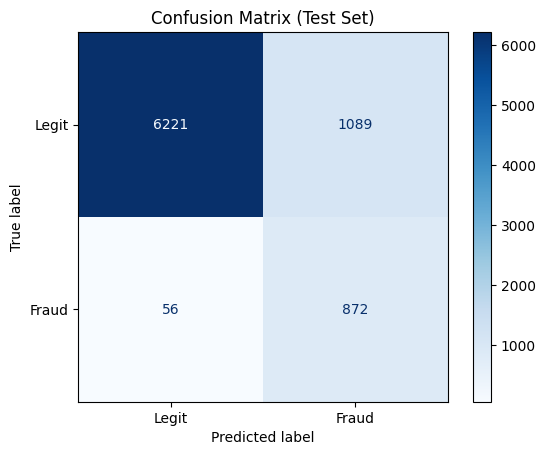

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Test Set)")
plt.show()

In [34]:
model = CatBoostClassifier(iterations=1000, learning_rate=0.01, depth=5,  auto_class_weights = "Balanced")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = classification_report(y_test, y_pred)
print(accuracy)

0:	learn: 0.6842311	total: 21.2ms	remaining: 21.2s
1:	learn: 0.6752057	total: 50.4ms	remaining: 25.2s
2:	learn: 0.6667673	total: 62.9ms	remaining: 20.9s
3:	learn: 0.6587018	total: 74.2ms	remaining: 18.5s
4:	learn: 0.6494571	total: 82.3ms	remaining: 16.4s
5:	learn: 0.6418351	total: 89.5ms	remaining: 14.8s
6:	learn: 0.6334934	total: 97.4ms	remaining: 13.8s
7:	learn: 0.6248130	total: 106ms	remaining: 13.2s
8:	learn: 0.6177411	total: 118ms	remaining: 13s
9:	learn: 0.6106043	total: 125ms	remaining: 12.4s
10:	learn: 0.6037163	total: 132ms	remaining: 11.9s
11:	learn: 0.5955252	total: 141ms	remaining: 11.6s
12:	learn: 0.5904553	total: 151ms	remaining: 11.5s
13:	learn: 0.5843007	total: 158ms	remaining: 11.1s
14:	learn: 0.5775160	total: 165ms	remaining: 10.8s
15:	learn: 0.5713360	total: 173ms	remaining: 10.6s
16:	learn: 0.5649896	total: 180ms	remaining: 10.4s
17:	learn: 0.5591016	total: 186ms	remaining: 10.1s
18:	learn: 0.5537499	total: 198ms	remaining: 10.2s
19:	learn: 0.5481270	total: 206ms	re

In [46]:
model = LGBMClassifier(
    max_depth=5, learning_rate=0.1, n_estimators=100, auto_class_weights = "Balanced"
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = classification_report(y_test, y_pred)
print(accuracy)

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7310
           1       0.70      0.56      0.62       928

    accuracy                           0.92      8238
   macro avg       0.82      0.76      0.79      8238
weighted avg       0.92      0.92      0.92      8238



In [47]:
model2 = XGBClassifier( max_depth=5, learning_rate=0.1, n_estimators=100, auto_class_weights = "Balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = classification_report(y_test, y_pred)
print(accuracy)

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7310
           1       0.70      0.56      0.62       928

    accuracy                           0.92      8238
   macro avg       0.82      0.76      0.79      8238
weighted avg       0.92      0.92      0.92      8238

